# **<center style="color: green;">Desafío - Predicción de churn</center>**

#### **Nombre:** Cristian Tobar Morales ###
#### **Curso:** Machine Learning ###

# **Descripción**
En la industria de las telecomunicaciones, la retención de clientes es un desafío clave para
las empresas. La fuga de clientes, también conocida como churn, es un problema que puede
tener un impacto significativo en los ingresos y la reputación de una empresa. Anticiparse a
la fuga de clientes y tomar medidas preventivas para retenerlos se ha convertido en una
prioridad estratégica. En este contexto, el objetivo de esta tarea es utilizar técnicas de
machine learning para desarrollar un modelo que pueda predecir la probabilidad de fuga de
clientes en una empresa de telecomunicaciones.

## El objetivo principal
Utilizar un enfoque basado en machine learning para
construir un modelo predictivo de fuga de clientes. El modelo será capaz de clasificar a los
clientes como "fugados" o "no fugados" en función de un conjunto de variables relevantes. El
objetivo es proporcionar a la empresa de telecomunicaciones una herramienta eficaz para
identificar a los clientes en riesgo de abandonar sus servicios, lo que permitirá tomar
medidas proactivas para retenerlos.

# **Análisis exploratorio de los datos**

In [1]:
# ==========================================
# 1. Importación de Librerías
# ==========================================
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: Preprocesamiento, modelado y evaluación
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Scikit-Learn: Algoritmos de Clasificación base
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

# Configuración estética para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [6]:
# ==========================================
# 2. Carga del Dataset
# ==========================================
try:
    # Cargar el dataset desde un archivo CSV
    df = pd.read_excel('/mnt/d/crist/OneDrive/Estudios/Latam_2024/5_Machine Learning/3/Desafio/Telco-Customer-Churn.xlsx')
    print("Dataset cargado exitosamente.\n")

    # Mostrar las primeras filas del dataset
    display(df.head())

    # Mostrar la estructura del dataset
    print("\nInformación del dataset:")
    df.info()

except FileNotFoundError:
    print("Error: El archivo no se encontró. Asegúrate de que el archivo esté en el directorio correcto.")
    exit(1)

Dataset cargado exitosamente.



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-

Con respecto a la información inicial del dataset se puede concluir:
- La cantidad de columnas: 21
- Cantidad de filas: 7043
- EL tipo de datos corresponde: float64(2), int64(2), str(17)

## Visualización inicial

/tmp/ipykernel_24042/1408766853.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, ax=axes[0], palette='Set2')
/tmp/ipykernel_24042/1408766853.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df, ax=axes[1], palette='Set2')


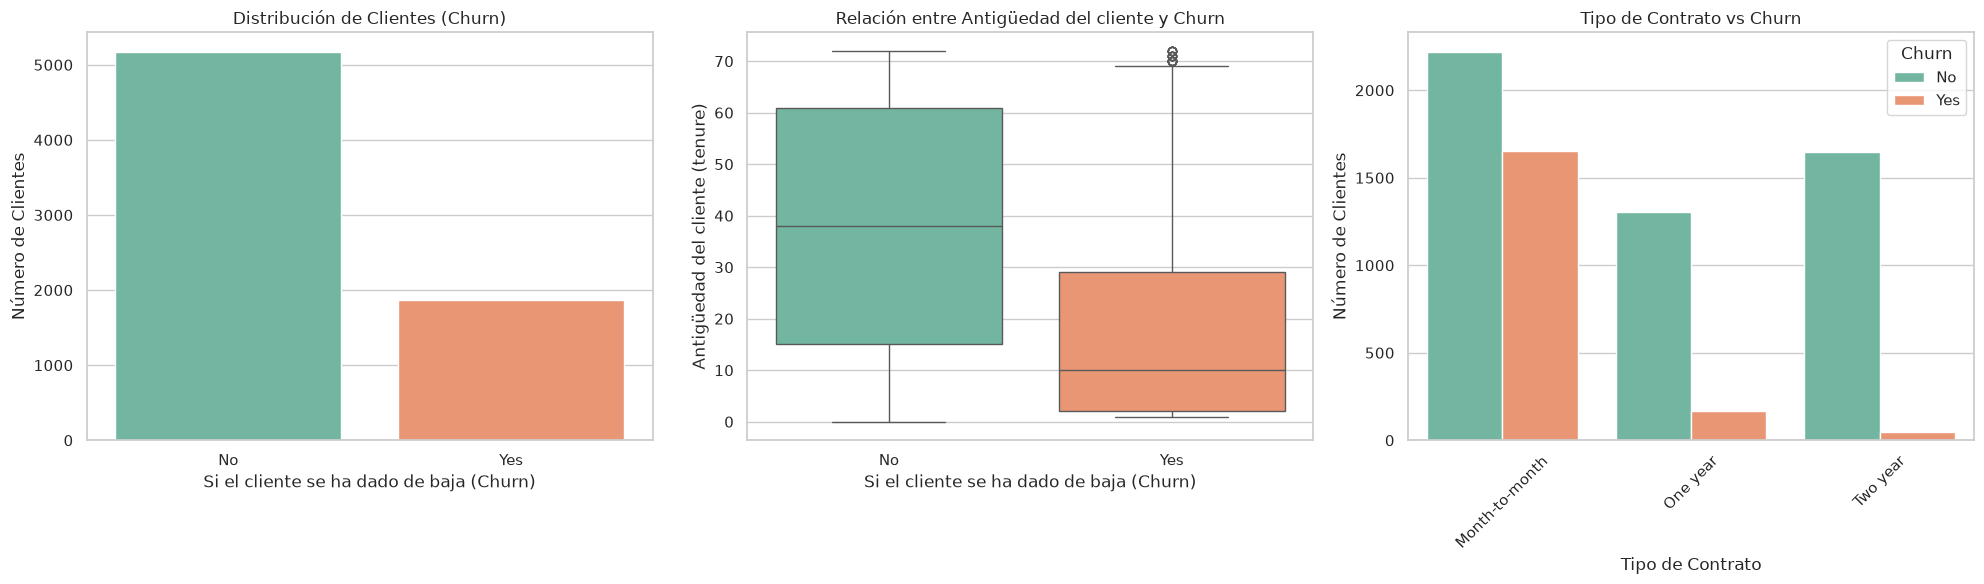

--- Resumen estadístico de las variables numéricas ---


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000



--- Proporción exacta de la variable objetivo (Churn) ---
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [7]:
# Crear un contenedeor para múltiples gráficos
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Gráfico 1: Distribución de la Variable Objetivo (Churn) ---
# Nos permite ver si el dataset está balanceado o desbalanceado
sns.countplot(x='Churn', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Distribución de Clientes (Churn)')
axes[0].set_xlabel('Si el cliente se ha dado de baja (Churn)')
axes[0].set_ylabel('Número de Clientes')

# --- Gráfico 2: Relación entre Antigüedad (tenure) y Churn ---
# Evaluamos si los clientes nuevos tienen mayor tendencia a irse
sns.boxplot(x='Churn', y='tenure', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Relación entre Antigüedad del cliente y Churn')
axes[1].set_xlabel('Si el cliente se ha dado de baja (Churn)')
axes[1].set_ylabel('Antigüedad del cliente (tenure)')

# --- Gráfico 3: Tipo de Contrato vs Churn ---
# Analizamos el impacto del tipo de contrato (Mensual, Anual, etc.) en la fuga
sns.countplot(x='Contract', hue='Churn', data=df, ax=axes[2], palette='Set2')
axes[2].set_title('Tipo de Contrato vs Churn')
axes[2].set_xlabel('Tipo de Contrato')
axes[2].set_ylabel('Número de Clientes')
axes[2].tick_params(axis='x', rotation=45)

# Ajustar el diseño para que no se superpongan los elementos
plt.tight_layout()
plt.show()

# Resumen numérico de las variables claves  
print("--- Resumen estadístico de las variables numéricas ---")
display(df.describe())

print("\n--- Proporción exacta de la variable objetivo (Churn) ---")
print(df['Churn'].value_counts(normalize=True) * 100)


Que se observa de los gráficos:
-	La distribución de los clientes, se pude apreciar la cantidad de clientes que no se fugan es mucho mayor que los que sí. Esta gran diferencia puede afectar los modelos mas adelante. 
-	El factor tiempo, el boxplot muestra que la mediana de antigüedad de los clientes fugados es muy baja.
-	La inmensa mayoría del Churn ocurre en contratos mensuales, lo que convierte a esta variable en un predictor crucial. 


# **Preprocesamiento de Datos**
Para este dataset en particular, existen tres tareas críticas que debemos realizar antes de entrenar cualquier algoritmo:

- Limpieza oculta: La columna TotalCharges suele ser leída como texto (object) porque tiene espacios en blanco (' ') para los clientes nuevos que llevan 0 meses. Hay que forzarla a numérica.

- Codificación de variables categóricas: Algoritmos como la Regresión Logística necesitan números. Convertiremos las variables de "Yes/No" a 1/0, y aplicaremos One-Hot Encoding para variables con múltiples categorías (como el tipo de contrato).

- Escalado de datos: Variables numéricas como tenure o MonthlyCharges tienen rangos muy distintos y necesitan estandarizarse para no sesgar algoritmos basados en distancias o gradientes.